In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


In [2]:
data = pd.read_csv('morraco_measurments.csv')
data.head()

,location_id,location_name,parameter,value,unit,datetimeUtc,datetimeLocal,timezone,latitude,longitude,country_iso,isMobile,isMonitor,owner_name,provider
0,2851582,Marrakech-Residence Mima,pm25,20.615476,µg/m³,2025-11-01T01:00:00Z,2025-11-01T02:00:00+01:00,Africa/Casablanca,31.660974,-8.027883,NaN,NaN,NaN,campus,AirGradient
1,2851582,Marrakech-Residence Mima,pm25,22.909375,µg/m³,2025-11-01T02:00:00Z,2025-11-01T03:00:00+01:00,Africa/Casablanca,31.660974,-8.027883,NaN,NaN,NaN,campus,AirGradient
2,2851582,Marrakech-Residence Mima,pm25,22.472619,µg/m³,2025-11-01T03:00:00Z,2025-11-01T04:00:00+01:00,Africa/Casablanca,31.660974,-8.027883,NaN,NaN,NaN,campus,AirGradient
3,2851582,Marrakech-Residence Mima,pm25,33.091816,µg/m³,2025-11-01T04:00:00Z,2025-11-01T05:00:00+01:00,Africa/Casablanca,31.660974,-8.027883,NaN,NaN,NaN,campus,AirGradient
4,2851582,Marrakech-Residence Mima,pm25,39.166369,µg/m³,2025-11-01T05:00:00Z,2025-11-01T06:00:00+01:00,Africa/Casablanca,31.660974,-8.027883,NaN,NaN,NaN,campus,AirGradient


## Data Wrangling

In [3]:
def wrangle_data(path, resample_rule="1h"):
    # read the data from the csv file
    data = pd.read_csv(path)

    # Select only the relevant columns
    df = data[["datetimeLocal","value"]] 
    df = df.rename(columns={"datetimeLocal": "timestamp", "value": "pm25"})
    
    # Convert 'Date' column to datetime
    df['timestamp'] = pd.to_datetime(df['timestamp'],utc=True)
    # Set 'Date' column as index
    df.set_index("timestamp", inplace=True)
    
    # Resample and fill with interpolate
    df = df["pm25"].resample(resample_rule).mean().interpolate()

    
    
    return df

In [4]:
df = wrangle_data('morraco_measurments.csv', resample_rule="1h")
df.head()

timestamp
2025-11-01 01:00:00+00:00    20.615476
2025-11-01 02:00:00+00:00    22.909375
2025-11-01 03:00:00+00:00    22.472619
2025-11-01 04:00:00+00:00    33.091816
2025-11-01 05:00:00+00:00    39.166369
Freq: h, Name: pm25, dtype: float64

In [5]:
df.isna().sum()

0

In [6]:
df[df.isna()]

Series([], Freq: h, Name: pm25, dtype: float64)

In [7]:
df.describe()

count    2664.000000
mean       26.133237
std        14.791596
min         1.369792
25%        15.731659
50%        24.493924
75%        34.541071
max       137.890332
Name: pm25, dtype: float64

## ploting the distribution of the data

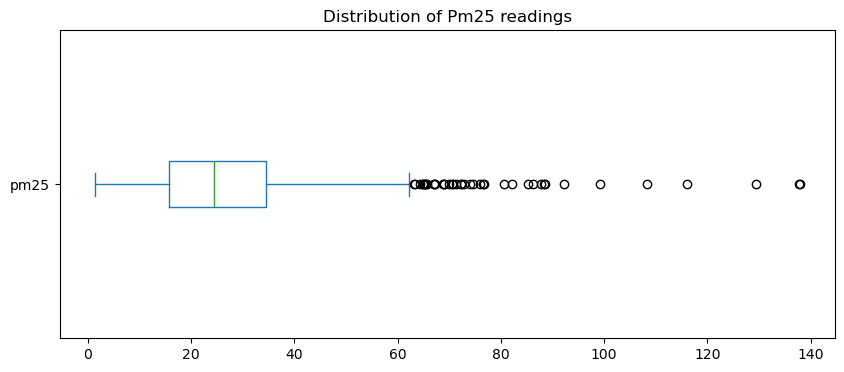

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
df.plot(kind="box",vert=False,title = "Distribution of Pm25 readings");

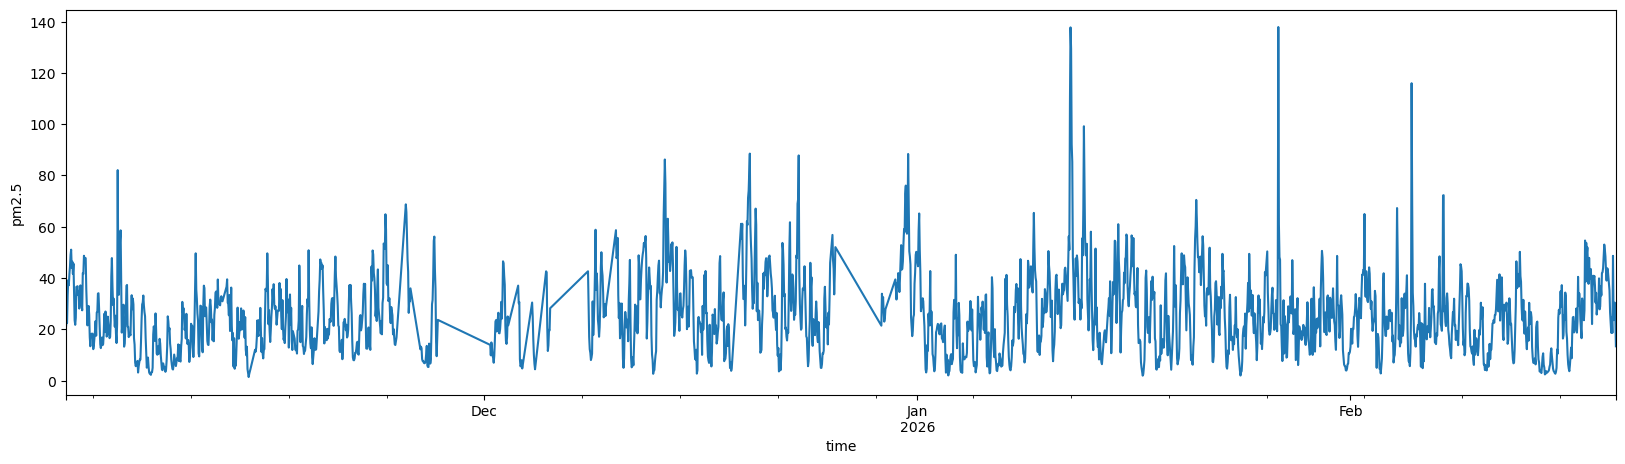

In [9]:
fig, ax = plt.subplots(figsize=(20,5))
df.plot(xlabel="time",ylabel="pm2.5",ax=ax);

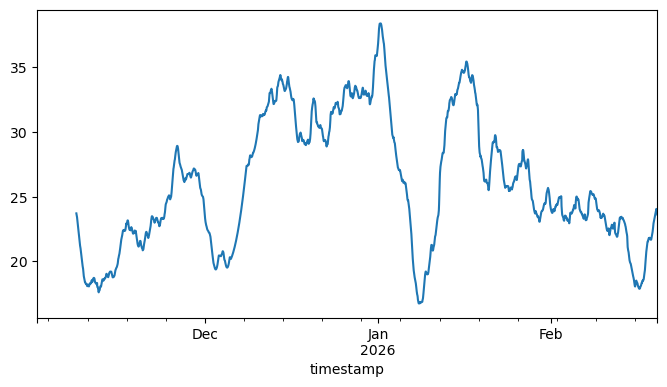

In [10]:
fig, ax = plt.subplots(figsize=(8,4))
df.rolling(168).mean().plot(ax=ax);

In [11]:
df.corr(df.shift(1))

0.8328791251061846

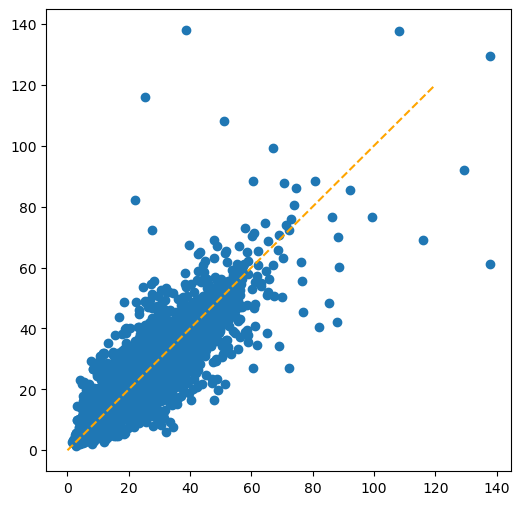

In [12]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x=df.shift(1), y=df)
ax.plot([0,120],[0,120],linestyle="--",color="orange");

## Auto corrolation & partial auto corr

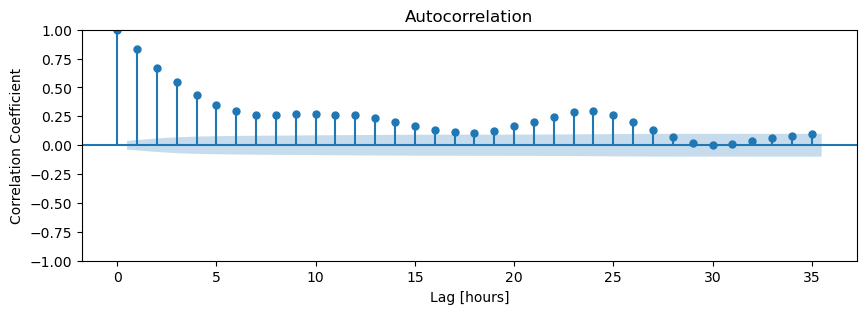

In [128]:
fig, ax = plt.subplots(figsize=(10, 3))
plot_acf(df, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient");

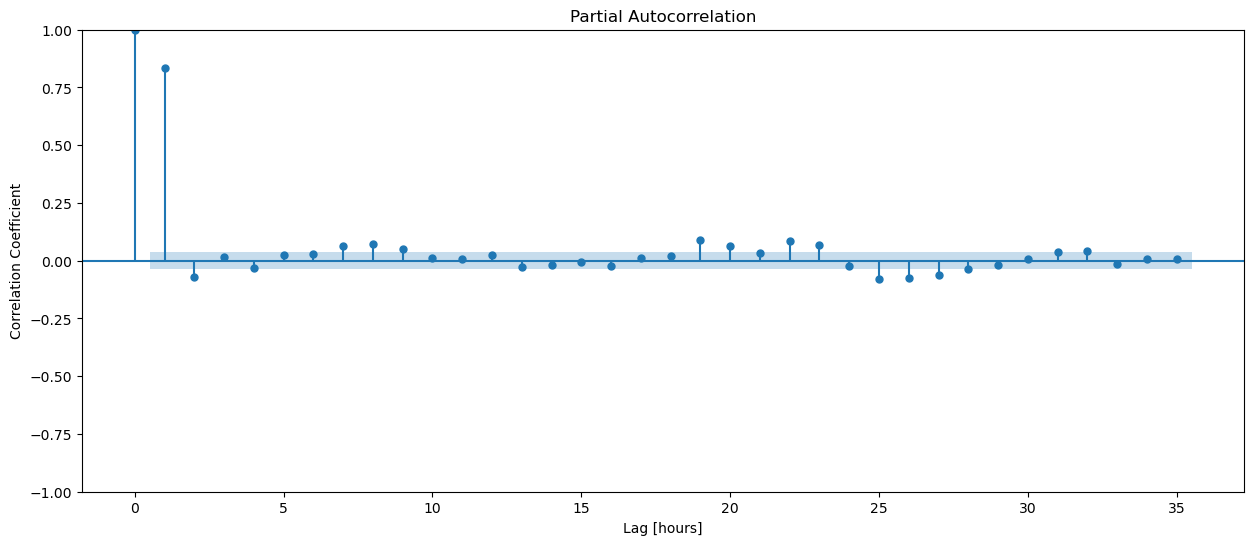

In [129]:
fig, ax = plt.subplots(figsize=(15, 6))
plot_pacf(df, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient");

## ADF test

The ADF test is a formal statistical test used to determine if a time series is stationary.<br>
It works by testing a Null Hypothesis  ($H_0$):<br>
Null Hypothesis ($H_0$): The series is not stationary (it has a unit root).<br>
Alternative Hypothesis ($H_a$): The series is stationary.<br>
How to interpret the results:When you run the test, you look at the p-value:p-value $\le$ 0.05: Reject the Null Hypothesis. Your data is Stationary.p-value $>$ 0.05: Fail to reject the Null Hypothesis. Your data is Non-Stationary.

In [134]:
from statsmodels.tsa.stattools import adfuller

# Run the Augmented Dickey-Fuller test
result = adfuller(df)

print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

if result[1] <= 0.05:
    print("Conclusion: The data is stationary.")
else:
    print("Conclusion: The data is non-stationary.")

ADF Statistic: -7.375525506232354
p-value: 8.743158670908559e-11
Conclusion: The data is stationary.
